In [85]:
# Import dependencies
from matplotlib import pyplot as plt
from scipy.stats import linregress
import numpy as np
import pandas as pd
import datetime as dt

# Compare different factors in the LAPD dataset

In [86]:
# Read the csv file into a pandas DataFrame
df0 = pd.read_csv("resources/cleaned_data/crime_2020.csv")
df1 = pd.read_csv("resources/cleaned_data/crime_2021.csv")
df2 = pd.read_csv("resources/cleaned_data/crime_2022.csv")
df3 = pd.read_csv("resources/cleaned_data/crime_2023.csv")

df = pd.concat([df0,df1,df2,df3], axis=0, ignore_index=True)
# Review the DataFrame
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,crime_timestamp,Year
0,190326475,03/01/2020 12:00:00 AM,2020-03-01,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506,2020-03-01 21:30:00,2020
1,200106753,02/09/2020 12:00:00 AM,2020-02-08,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628,2020-02-08 18:00:00,2020
2,200320258,11/11/2020 12:00:00 AM,2020-11-04,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002,2020-11-04 17:00:00,2020
3,200907217,05/10/2023 12:00:00 AM,2020-03-10,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387,2020-03-10 20:37:00,2020
4,200412582,09/09/2020 12:00:00 AM,2020-09-09,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130,2020-09-09 06:30:00,2020


In [87]:
df = df[['Crm Cd', 'Date Rptd']]
df.head()

,Crm Cd,Date Rptd
0,510,03/01/2020 12:00:00 AM
1,330,02/09/2020 12:00:00 AM
2,480,11/11/2020 12:00:00 AM
3,343,05/10/2023 12:00:00 AM
4,510,09/09/2020 12:00:00 AM


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877184 entries, 0 to 877183
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Crm Cd     877184 non-null  int64 
 1   Date Rptd  877184 non-null  object
dtypes: int64(1), object(1)
memory usage: 13.4+ MB


In [89]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877184 entries, 0 to 877183
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Crm Cd     877184 non-null  int64         
 1   Date Rptd  877184 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 13.4 MB


/var/folders/nn/h8r4zj6x03jgg9nnxtcg6n0h0000gn/T/ipykernel_12615/5072033.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])


,Crm Cd,Date Rptd
0,510,2020-03-01
1,330,2020-02-09
2,480,2020-11-11
3,343,2023-05-10
4,510,2020-09-09


In [90]:
df.describe()

,Crm Cd,Date Rptd
count,877184.000000,877184
mean,500.634570,2022-02-08 06:30:21.505180160
min,110.000000,2020-01-01 00:00:00
25%,331.000000,2021-02-20 00:00:00
50%,442.000000,2022-03-02 00:00:00
75%,626.000000,2023-02-03 00:00:00
max,956.000000,2025-02-27 00:00:00
std,207.588477,NaN


In [91]:
df = df.loc[df['Date Rptd'] < pd.Timestamp('2024-01-01')]
df.describe()

,Crm Cd,Date Rptd
count,870621.000000,870621
mean,500.729135,2022-02-02 11:14:06.153263360
min,110.000000,2020-01-01 00:00:00
25%,331.000000,2021-02-17 00:00:00
50%,442.000000,2022-02-26 00:00:00
75%,626.000000,2023-01-27 00:00:00
max,956.000000,2023-12-31 00:00:00
std,207.642683,NaN


# Linear Regression on Daily Crime

In [92]:
daily_counts = df.groupby(pd.Grouper(key='Date Rptd', freq='D')).size()
daily_counts.head(10)

Date Rptd
2020-01-01    354
2020-01-02    398
2020-01-03    403
2020-01-04    436
2020-01-05    420
2020-01-06    517
2020-01-07    479
2020-01-08    498
2020-01-09    503
2020-01-10    517
Freq: D, dtype: int64

In [93]:
daily_counts_df = daily_counts.reset_index(name='Count')
daily_counts_df.columns = ['Daily', 'Count']
daily_counts_df.head()

,Daily,Count
0,2020-01-01,354
1,2020-01-02,398
2,2020-01-03,403
3,2020-01-04,436
4,2020-01-05,420


In [94]:
daily_counts_df.describe()

,Daily,Count
count,1461,1461.000000
mean,2021-12-31 00:00:00,595.907598
min,2020-01-01 00:00:00,349.000000
25%,2020-12-31 00:00:00,538.000000
50%,2021-12-31 00:00:00,591.000000
75%,2022-12-31 00:00:00,652.000000
max,2023-12-31 00:00:00,929.000000
std,NaN,86.173608


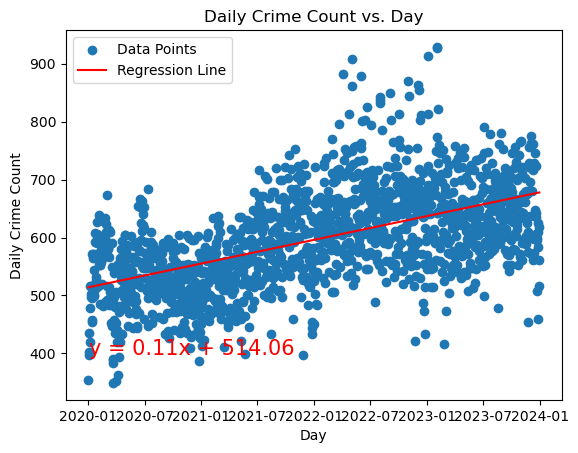

The r-squared is: 0.3013356237271663


In [96]:
# Plot out time vs crimes
x_values = daily_counts_df['Daily'].map(pd.Timestamp.timestamp)
y_values = daily_counts_df['Count']

daily_counts_df['date_numeric'] = (daily_counts_df['Daily'] - daily_counts_df['Daily'].min()).dt.days
x_values = daily_counts_df['date_numeric']
# Add the linear regression equation and line to plot
(slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
regress_values = x_values * slope + intercept
line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))

plt.scatter(daily_counts_df['Daily'], y_values, label='Data Points')
plt.plot(daily_counts_df['Daily'], regress_values, "r-", label='Regression Line')
plt.annotate(line_eq, (daily_counts_df['Daily'].iloc[1], y_values.iloc[1]), fontsize=15, color="red")
plt.xlabel('Day')
plt.ylabel('Daily Crime Count')
plt.title('Daily Crime Count vs. Day')
plt.legend()
plt.show()
print(f"The r-squared is: {rvalue**2}")

# Linear Regression on Weekly Crime

In [57]:
weekly_counts = df.groupby(pd.Grouper(key='Date Rptd', freq='W')).size()
weekly_counts.head(10)

Date Rptd
2020-01-05    2011
2020-01-12    3427
2020-01-19    3720
2020-01-26    3886
2020-02-02    4049
2020-02-09    3941
2020-02-16    3904
2020-02-23    4031
2020-03-01    4073
2020-03-08    3990
Freq: W-SUN, dtype: int64

In [58]:
weekly_counts_df = weekly_counts.reset_index(name='Count')
weekly_counts_df.columns = ['Week', 'Count']
weekly_counts_df.head()

,Week,Count
0,2020-01-05,2011
1,2020-01-12,3427
2,2020-01-19,3720
3,2020-01-26,3886
4,2020-02-02,4049


In [59]:
weekly_counts_df.describe()

,Week,Count
count,209,209.000000
mean,2022-01-02 00:00:00,4165.650718
min,2020-01-05 00:00:00,2011.000000
25%,2021-01-03 00:00:00,3781.000000
50%,2022-01-02 00:00:00,4242.000000
75%,2023-01-01 00:00:00,4490.000000
max,2023-12-31 00:00:00,5336.000000
std,NaN,449.730077


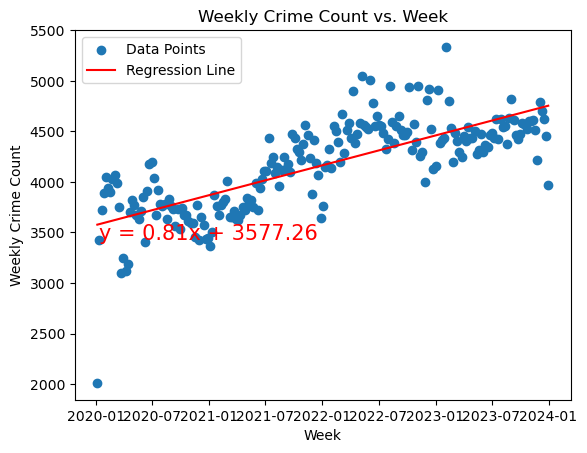

The r-squared is: 0.5788230261180906


In [98]:
# Plot out time vs crimes
x_values = weekly_counts_df['Week'].map(pd.Timestamp.timestamp)
y_values = weekly_counts_df['Count']

weekly_counts_df['date_numeric'] = (weekly_counts_df['Week'] - weekly_counts_df['Week'].min()).dt.days
x_values = weekly_counts_df['date_numeric']
# Add the linear regression equation and line to plot
(slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
regress_values = x_values * slope + intercept
line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))

plt.scatter(weekly_counts_df['Week'], y_values, label='Data Points')
plt.plot(weekly_counts_df['Week'], regress_values, "r-", label='Regression Line')
plt.annotate(line_eq, (weekly_counts_df['Week'].iloc[1], y_values.iloc[1]), fontsize=15, color="red")
plt.xlabel('Week')
plt.ylabel('Weekly Crime Count')
plt.title('Weekly Crime Count vs. Week')
plt.legend()
plt.show()
print(f"The r-squared is: {rvalue**2}")

# Linear Regression on Monthly Crime

In [62]:
monthly_counts = df.groupby(pd.Grouper(key='Date Rptd', freq='M')).size()
monthly_counts.head(10)

Date Rptd
2020-01-31    16060
2020-02-29    16490
2020-03-31    15539
2020-04-30    15179
2020-05-31    16331
2020-06-30    16955
2020-07-31    16907
2020-08-31    16605
2020-09-30    15636
2020-10-31    16142
Freq: M, dtype: int64

In [63]:
monthly_counts_df = monthly_counts.reset_index(name='Count')
monthly_counts_df.columns = ['Month', 'Count']
monthly_counts_df.head()

,Month,Count
0,2020-01-31,16060
1,2020-02-29,16490
2,2020-03-31,15539
3,2020-04-30,15179
4,2020-05-31,16331


In [64]:
monthly_counts_df.describe()

,Month,Count
count,48,48.000000
mean,2022-01-14 09:30:00,18137.937500
min,2020-01-31 00:00:00,15179.000000
25%,2021-01-23 06:00:00,16450.250000
50%,2022-01-15 12:00:00,18613.000000
75%,2023-01-07 18:00:00,19680.500000
max,2023-12-31 00:00:00,20596.000000
std,NaN,1725.236628


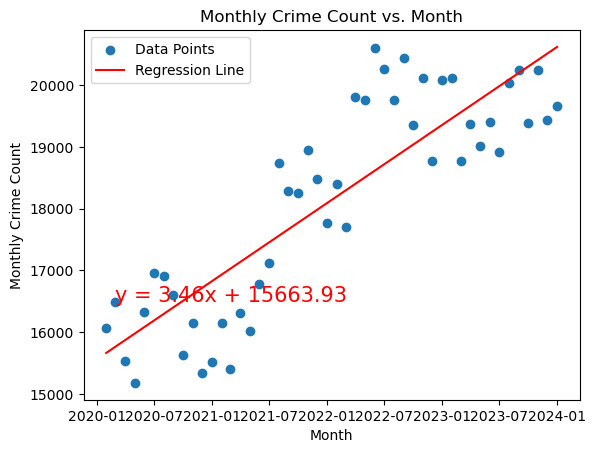

The r-squared is: 0.7309737052287066


In [99]:
# Plot out time vs crimes
x_values = monthly_counts_df['Month'].map(pd.Timestamp.timestamp)
y_values = monthly_counts_df['Count']

monthly_counts_df['date_numeric'] = (monthly_counts_df['Month'] - monthly_counts_df['Month'].min()).dt.days
x_values = monthly_counts_df['date_numeric']
# Add the linear regression equation and line to plot
(slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
regress_values = x_values * slope + intercept
line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))

plt.scatter(monthly_counts_df['Month'], y_values, label='Data Points')
plt.plot(monthly_counts_df['Month'], regress_values, "r-", label='Regression Line')
plt.annotate(line_eq, (monthly_counts_df['Month'].iloc[1], y_values.iloc[1]), fontsize=15, color="red")
plt.xlabel('Month')
plt.ylabel('Monthly Crime Count')
plt.title('Monthly Crime Count vs. Month')
plt.legend()
plt.show()
print(f"The r-squared is: {rvalue**2}")

# Linear Regression on Quarterly Crime

In [77]:
quarterly_counts = df.groupby(pd.Grouper(key='Date Rptd', freq='Q')).size()
quarterly_counts.head(10)

Date Rptd
2020-03-31    48089
2020-06-30    48465
2020-09-30    49148
2020-12-31    47004
2021-03-31    47872
2021-06-30    49923
2021-09-30    55283
2021-12-31    55204
2022-03-31    55903
2022-06-30    60621
Freq: Q-DEC, dtype: int64

In [78]:
quarterly_counts_df = quarterly_counts.reset_index(name='Count')
quarterly_counts_df.columns = ['Quarter', 'Count']
quarterly_counts_df.head()

,Quarter,Count
0,2020-03-31,48089
1,2020-06-30,48465
2,2020-09-30,49148
3,2020-12-31,47004
4,2021-03-31,47872


In [79]:
quarterly_counts_df.describe()

,Quarter,Count
count,16,16.000000
mean,2022-02-13 18:00:00,54413.812500
min,2020-03-31 00:00:00,47004.000000
25%,2021-03-08 12:00:00,48977.250000
50%,2022-02-14 00:00:00,55593.000000
75%,2023-01-22 12:00:00,59059.250000
max,2023-12-31 00:00:00,60621.000000
std,NaN,5068.224334


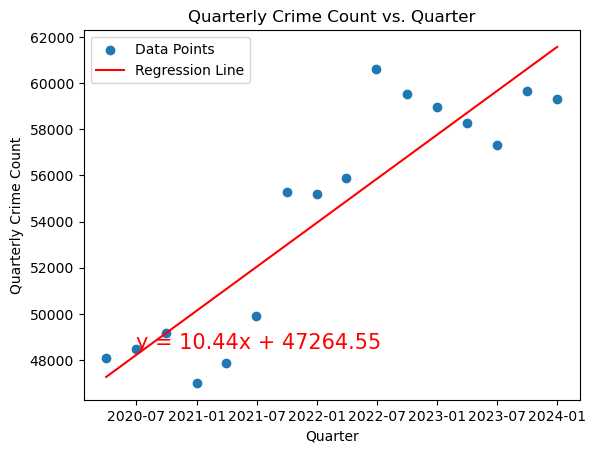

The r-squared is: 0.8014064711287323


In [100]:
# Plot out time vs crimes
x_values = quarterly_counts_df['Quarter'].map(pd.Timestamp.timestamp)
y_values = quarterly_counts_df['Count']

quarterly_counts_df['date_numeric'] = (quarterly_counts_df['Quarter'] - quarterly_counts_df['Quarter'].min()).dt.days
x_values = quarterly_counts_df['date_numeric']
# Add the linear regression equation and line to plot
(slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
regress_values = x_values * slope + intercept
line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))

plt.scatter(quarterly_counts_df['Quarter'], y_values, label='Data Points')
plt.plot(quarterly_counts_df['Quarter'], regress_values, "r-", label='Regression Line')
plt.annotate(line_eq, (quarterly_counts_df['Quarter'].iloc[1], y_values.iloc[1]), fontsize=15, color="red")
plt.xlabel('Quarter')
plt.ylabel('Quarterly Crime Count')
plt.title('Quarterly Crime Count vs. Quarter')
plt.legend()
plt.show()
print(f"The r-squared is: {rvalue**2}")

# Linear Regression on Yearly Crime

In [66]:
yearly_counts = df.groupby(pd.Grouper(key='Date Rptd', freq='Y')).size()
yearly_counts.head(10)

Date Rptd
2020-12-31    192706
2021-12-31    208282
2022-12-31    235043
2023-12-31    234590
Freq: A-DEC, dtype: int64

In [67]:
yearly_counts_df = yearly_counts.reset_index(name='Count')
yearly_counts_df.columns = ['Year', 'Count']
yearly_counts_df.head()

,Year,Count
0,2020-12-31,192706
1,2021-12-31,208282
2,2022-12-31,235043
3,2023-12-31,234590


In [68]:
yearly_counts_df.describe()

,Year,Count
count,4,4.000000
mean,2022-07-01 12:00:00,217655.250000
min,2020-12-31 00:00:00,192706.000000
25%,2021-09-30 18:00:00,204388.000000
50%,2022-07-01 12:00:00,221436.000000
75%,2023-04-01 06:00:00,234703.250000
max,2023-12-31 00:00:00,235043.000000
std,NaN,20812.195934


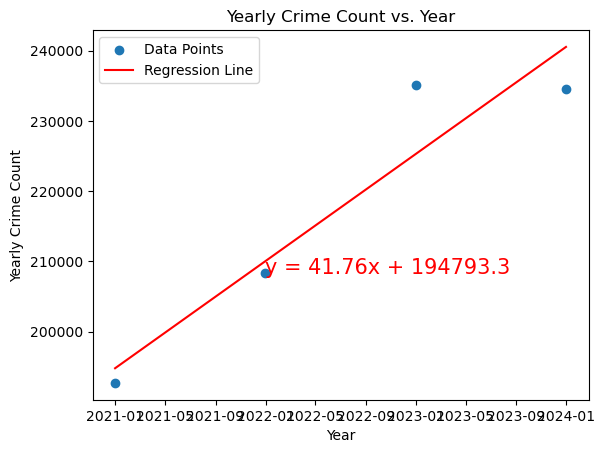

The r-squared is: 0.8938341862508675


In [101]:
# Plot out time vs crimes
x_values = yearly_counts_df['Year'].map(pd.Timestamp.timestamp)
y_values = yearly_counts_df['Count']

yearly_counts_df['date_numeric'] = (yearly_counts_df['Year'] - yearly_counts_df['Year'].min()).dt.days
x_values = yearly_counts_df['date_numeric']
# Add the linear regression equation and line to plot
(slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
regress_values = x_values * slope + intercept
line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))

plt.scatter(yearly_counts_df['Year'], y_values, label='Data Points')
plt.plot(yearly_counts_df['Year'], regress_values, "r-", label='Regression Line')
plt.annotate(line_eq, (yearly_counts_df['Year'].iloc[1], y_values.iloc[1]), fontsize=15, color="red")
plt.xlabel('Year')
plt.ylabel('Yearly Crime Count')
plt.title('Yearly Crime Count vs. Year')
plt.legend()
plt.show()
print(f"The r-squared is: {rvalue**2}")